# 🏠 Project 1: **House Price Prediction**
---
**Objective:** Predict house prices using the California Housing dataset.  
**Approach:** Linear Regression, Lasso (L1), and Ridge (L2) Regularization.


## Using Scikit learn Dataset

In [1]:
#load dataset
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame


In [2]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


# Expolratory Data Analysis (EDA)

In [3]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
df.shape

(20640, 9)

In [7]:
# detect duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
### Detect and Handle Outliers
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
q1 = df['MedHouseVal'].quantile(0.25)
q3 = df['MedHouseVal'].quantile(0.75)
IQR = q3 - q1
IQR

wisk_min = q1 - 1.5 * IQR
wisk_max = q3 + 1.5 * IQR

df[(df['MedHouseVal'] < wisk_min) | (df['MedHouseVal'] > wisk_max)]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
89,1.2434,52.0,2.929412,0.917647,396.0,4.658824,37.80,-122.27,5.00001
140,6.3624,30.0,5.615385,0.730769,126.0,2.423077,37.81,-122.18,4.83300
459,1.1696,52.0,2.436000,0.944000,1349.0,5.396000,37.87,-122.25,5.00001
489,3.0417,48.0,4.690632,1.126362,1656.0,3.607843,37.86,-122.25,4.89600
493,7.8521,52.0,7.794393,1.051402,517.0,2.415888,37.86,-122.24,5.00001
...,...,...,...,...,...,...,...,...,...
20422,5.1457,35.0,6.958333,1.217593,576.0,2.666667,34.14,-118.90,5.00001
20426,10.0472,11.0,9.890756,1.159664,415.0,3.487395,34.18,-118.69,5.00001
20427,8.6499,4.0,7.236059,1.032528,5495.0,2.553439,34.19,-118.80,5.00001
20436,12.5420,10.0,9.873315,1.102426,1179.0,3.177898,34.21,-118.69,5.00001


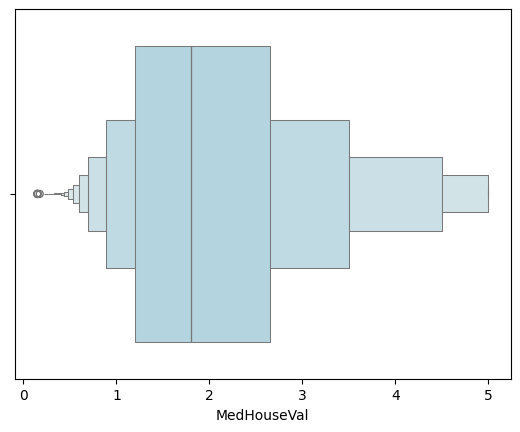

In [9]:
sns.boxenplot(x=df['MedHouseVal'], color='lightblue')
plt.show()

## 🧹 Data Quality & Cleaning

Before building the model, the dataset was carefully inspected to ensure its quality and consistency.

- ✅ No missing values were detected  
- ✅ No duplicated records were found  
- ✅ All features are already in numerical format  

As a result, the dataset is considered **clean and well-prepared for modeling**, and no additional data cleaning or preprocessing steps were required.


### Train Test Split

In [10]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (16512, 8)
X_test shape: (4128, 8)


array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

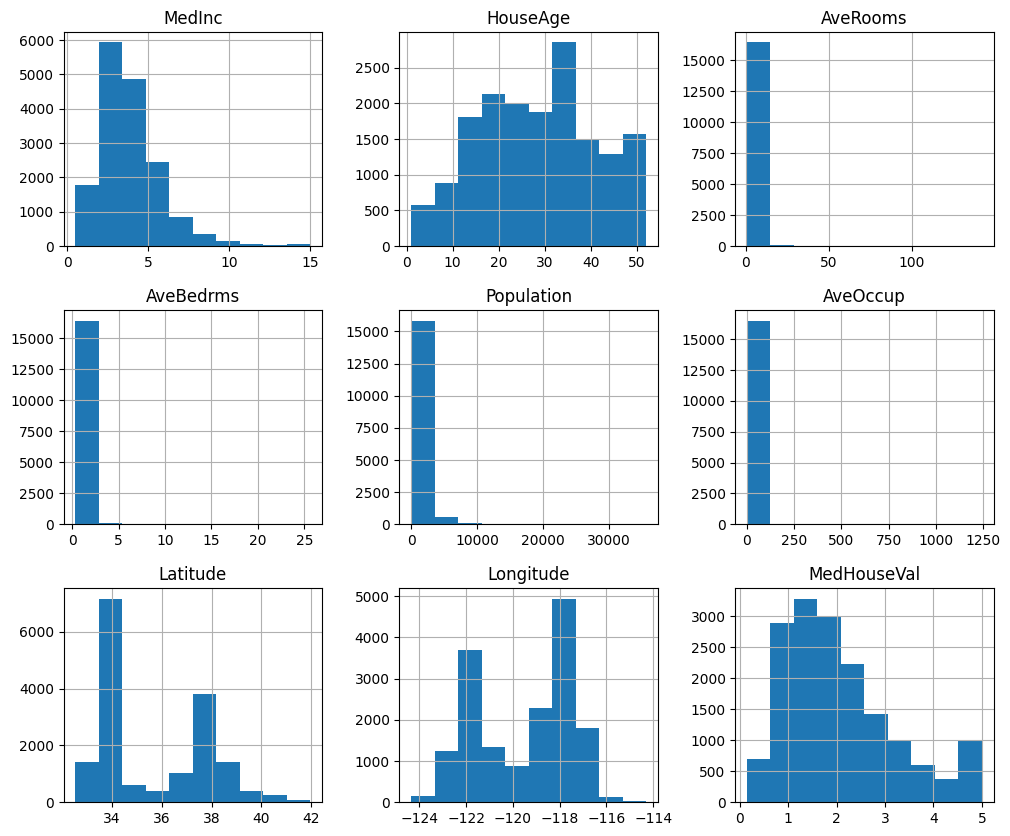

In [12]:
# Visualize the distribution of features in the training set
import pandas as pd
train_data = pd.concat([X_train, y_train], axis=1)
train_data.hist(figsize=(12,10))

In [13]:
train_data.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.121711,0.336013,-0.072550,0.004122,0.022061,-0.076571,-0.017040,0.690647
HouseAge,-0.121711,1.000000,-0.160892,-0.087983,-0.292283,0.016245,0.005296,-0.101818,0.103706
AveRooms,0.336013,-0.160892,1.000000,0.836163,-0.073733,-0.004922,0.110695,-0.029339,0.158485
AveBedrms,-0.072550,-0.087983,0.836163,1.000000,-0.071267,-0.006035,0.073161,0.016647,-0.051351
Population,0.004122,-0.292283,-0.073733,-0.071267,1.000000,0.072330,-0.102499,0.094276,-0.026032
AveOccup,0.022061,0.016245,-0.004922,-0.006035,0.072330,1.000000,0.005837,-0.000598,-0.022030
Latitude,-0.076571,0.005296,0.110695,0.073161,-0.102499,0.005837,1.000000,-0.924485,-0.142983
Longitude,-0.017040,-0.101818,-0.029339,0.016647,0.094276,-0.000598,-0.924485,1.000000,-0.046349
MedHouseVal,0.690647,0.103706,0.158485,-0.051351,-0.026032,-0.022030,-0.142983,-0.046349,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

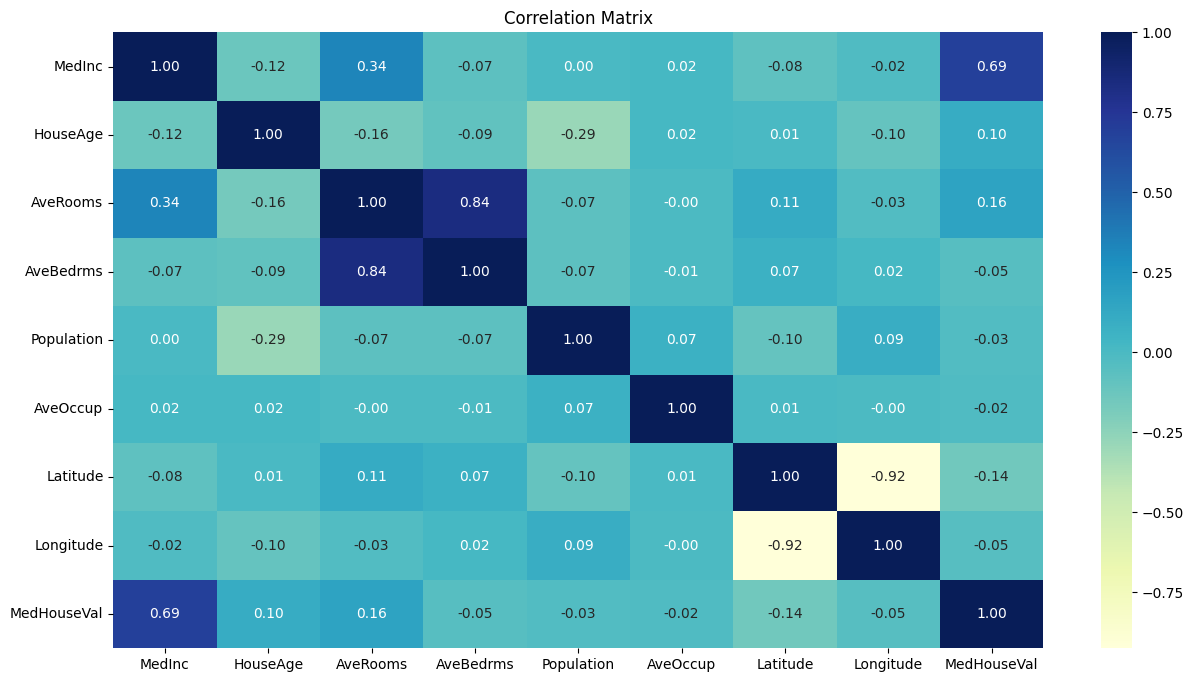

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Correlation Matrix")

### Ready for Modeling

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score, mean_squared_error


In [16]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("RMSE:", rmse)
print("R² Score:", r2)

# Display coefficients
print("Coefficients (m):", model.coef_)
print("Intercept (b):", model.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))


RMSE: 0.7455813830127761
R² Score: 0.5757877060324511
Coefficients (m): [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercept (b): -37.023277706064064
MSE: 0.555891598695244


In [18]:
import pandas as pd
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)


,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


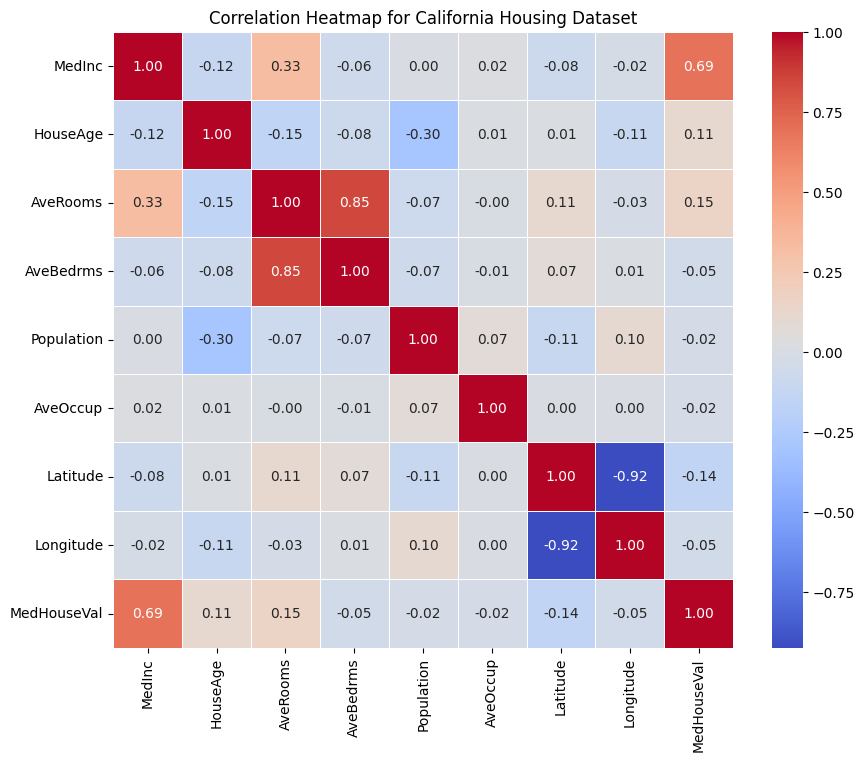

In [19]:
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap for California Housing Dataset")
plt.show()


# Save the model

In [20]:

import joblib

joblib.dump(model, "house_price_model.pkl")


['house_price_model.pkl']

In [21]:
sample_house = [[
    5.0,   # MedInc
    10,    # HouseAge
    6.0,   # AveRooms
    1.0,   # AveBedrms
    500,   # Population
    2.5,   # AveOccup
    37.8,  # Latitude
    -122.2 # Longitude
]]

prediction = model.predict(sample_house)
print("Predicted House Value:", prediction[0])


Predicted House Value: 2.4816832063201133


c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Model Regularization with L1 and L2 

In [22]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [24]:
# Baseline Linear Regression
lr = LinearRegression()

# Lasso (L1 regularization)
lasso = Lasso(alpha=0.1)  # alpha = regularization strength

# Ridge (L2 regularization)
ridge = Ridge(alpha=1.0)


In [25]:
# regularization models with lasso 
models = {
    "Linear Regression": lr,
    "Lasso Regression": lasso,
    "Ridge Regression": ridge
}
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name} - RMSE: {rmse}, R²: {r2}")   
    results[name] = {"RMSE": rmse, "R2": r2}

Linear Regression - RMSE: 0.7455813830127764, R²: 0.5757877060324508
Lasso Regression - RMSE: 0.8243961598848472, R²: 0.48136113250290735
Ridge Regression - RMSE: 0.7455567442814779, R²: 0.5758157428913684


In [26]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df


,RMSE,R2
Linear Regression,0.745581,0.575788
Lasso Regression,0.824396,0.481361
Ridge Regression,0.745557,0.575816


### Comparison of Regularization Techniques

We compared three models: Linear Regression, Lasso (L1 regularization), and Ridge (L2 regularization).

| Model               | RMSE  | R²   |
|--------------------|-------|------|
| Linear Regression  | 0.745581   | 0.575788  |
| Lasso (L1)         | 0.824396   | 0.481361  |
| Ridge (L2)         | 0.745557   | 0.575816  |

Observations:
- Lasso can shrink some coefficients to zero, effectively performing feature selection.
- Ridge reduces large coefficients without eliminating features.
- The regularized models can help reduce overfitting and improve generalization compared to the baseline Linear Regression.
